In [1]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import time
from tensorflow.keras import layers, Model

In [2]:
image_folder = "flood_dataset"

files = [f for f in os.listdir(image_folder) 
         if f.endswith((".png", ".jpg", ".jpeg"))]

print("Total images:", len(files))
print("Files:" , files)

Total images: 52
Files: ['2015_0.6_3239.jpg', '2015_ORG.jpg', '2005_ORG.jpg', '2005_1.2_2600.jpg', '1985_1.6_1849.6.jpg', '1991_2.0_1234.jpg', '2015_1.4_3239.jpg', '1998_1.6_428.jpg', '2020_0.6_1276.6.jpg', '2023_ORG.jpg', '1985_2.0_1849.6.jpg', '1998_ORG.jpg', '2023_0.6_2718.jpg', '1991_ORG.jpg', '2008_1.4_1427.jpg', '2020_ORG.jpg', '1991_1.2_1234.jpg', '1991_1.8_1234.jpg', '1985_0.4_1849.6.jpg', '1976_ORG.jpg', '2005_1.4_2600.jpg', '1976_1.4_3036.jpg', '1998_1.4_428.jpg', '2015_1.2_3239.jpg', '1998_2.0_428.jpg', '2020_1.4_1276.6.jpg', '2005_0.6_2600.jpg', '1991_0.4_1234.jpg', '2023_1.6_2718.jpg', '2008_0.8_1427.jpg', '1991_1.6_1234.jpg', '1998_1.8_428.jpg', '2020_1.2_1276.6.jpg', '1976_0.2_3036.jpg', '1996_ORG.jpg', '1985_0.2_1849.6.jpg', '1996_1.2_1416.jpg', '2005_0.8_2600.jpg', '2015_0.8_3239.jpg', '2020_1.8_1276.6.jpg', '1996_0.6_1416.jpg', '2005_0.4_2600.jpg', '2015_0.2_3239.jpg', '1985_0.8_1849.6.jpg', '2005_1.6_2600.jpg', '2008_ORG.jpg', '1996_2.0_1416.jpg', '2023_0.8_2718.jpg'

In [3]:
def create_mask(img):
    colors = np.array([
        [0,255,0],
        [100,255,100],
        [0,255,255],
        [0,0,255],
        [0,0,139]
    ])

    img_flat = img.reshape(-1,3)
    distances = np.linalg.norm(img_flat[:, None] - colors, axis=2)
    mask = np.argmin(distances, axis=1)

    return mask.reshape(img.shape[0], img.shape[1])

In [4]:
images = []
masks = []

for filename in files:
    path = os.path.join(image_folder, filename)

    img = cv2.imread(path)
    img = cv2.resize(img, (256,256))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    mask = create_mask(img)

    images.append(img)
    masks.append(mask)

images = np.array(images) / 255.0
masks = np.array(masks)

print("Images:", images.shape)
print("Masks:", masks.shape)

Images: (61, 256, 256, 3)
Masks: (61, 256, 256)


In [5]:
# 1. Simple CNN (Local context only)
def build_cnn():
    return tf.keras.Sequential([
        layers.Input(shape=(256, 256, 3)),
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.Conv2D(5, (1, 1), activation='softmax')
    ])

# 2. FCNN (Encoder-Decoder without Skip Connections)
def build_fcnn():
    inputs = layers.Input((256, 256, 3))
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    x = layers.Conv2DTranspose(64, (2, 2), strides=2, padding='same')(x)
    x = layers.Conv2DTranspose(32, (2, 2), strides=2, padding='same')(x)
    outputs = layers.Conv2D(5, (1, 1), activation='softmax')(x)
    return Model(inputs, outputs)

# 3. U-Net (Encoder-Decoder with Skip Connections)
def conv_block(x, filters):
    x = layers.Conv2D(filters, (3, 3), padding='same', activation='relu')(x)
    return layers.Conv2D(filters, (3, 3), padding='same', activation='relu')(x)

def build_unet():
    inputs = layers.Input((256, 256, 3))
    # Encoder
    c1 = conv_block(inputs, 32); p1 = layers.MaxPooling2D((2, 2))(c1)
    c2 = conv_block(p1, 64); p2 = layers.MaxPooling2D((2, 2))(c2)
    # Bottleneck
    b1 = conv_block(p2, 128)
    # Decoder
    d1 = layers.Conv2DTranspose(64, (2, 2), strides=2, padding='same')(b1)
    d1 = layers.concatenate([d1, c2])
    d1 = conv_block(d1, 64)
    d2 = layers.Conv2DTranspose(32, (2, 2), strides=2, padding='same')(d1)
    d2 = layers.concatenate([d2, c1])
    d2 = conv_block(d2, 32)
    outputs = layers.Conv2D(5, (1, 1), activation='softmax')(d2)
    return Model(inputs, outputs)

In [6]:
models = {"Simple_CNN": build_cnn(), "FCNN": build_fcnn(), "U-Net": build_unet()}
history_logs = {}
comparison_data = []

for name, model in models.items():
    print(f"\n--- Training {name} ---")
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    start = time.time()
    history = model.fit(images, masks, epochs=20, batch_size=2, verbose=0) # batch_size=2 for stability
    duration = time.time() - start
    
    comparison_data.append({
        "Model": name,
        "Final Train Acc": history.history['accuracy'][-1],
        "Time (s)": round(duration, 2)
    })
    history_logs[name] = history

# Display Comparison Table
df = pd.DataFrame(comparison_data)
print("\nSummary Statistics:")
print(df)


--- Training Simple_CNN ---

--- Training FCNN ---

--- Training U-Net ---

Summary Statistics:
        Model  Final Train Acc  Time (s)
0  Simple_CNN         0.994798     42.02
1        FCNN         0.978629     26.19
2       U-Net         0.994022    209.35


In [7]:
all_models = {
    "CNN": models["Simple_CNN"],
    "FCNN": models["FCNN"],
    "U-Net": models["U-Net"]
}

for name, model in all_models.items():
    print(f"Training {name}...")
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    model.fit(images, masks, epochs=50, batch_size=3, verbose=0) 
print("All models trained.")

Training CNN...
Training FCNN...
Training U-Net...
All models trained.


Predicting for image index: 49 (2015_0.2_3239.jpg)


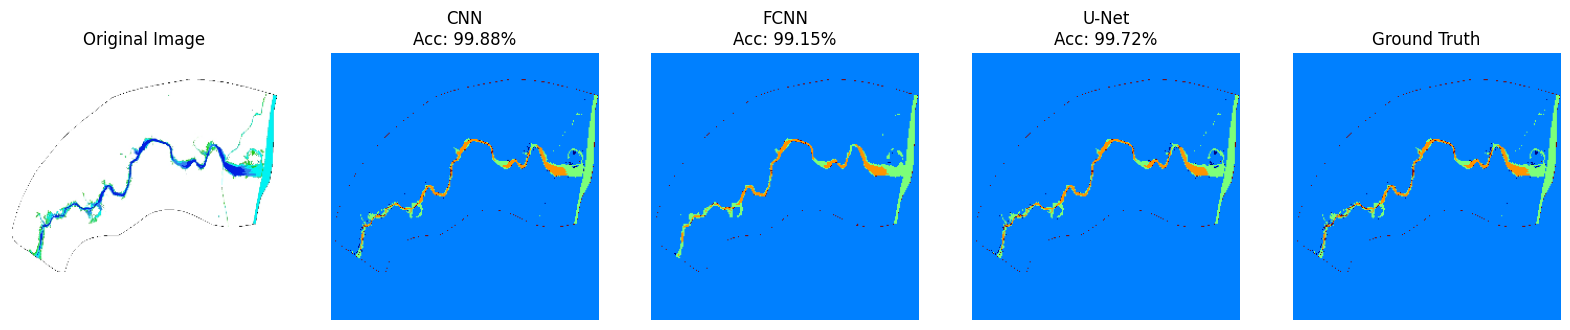

In [16]:
# Select a random image from images
random_idx = np.random.randint(0, len(images))
test_img = images[random_idx]
true_mask = masks[random_idx]

print(f"Predicting for image index: {random_idx} ({files[random_idx]})")

plt.figure(figsize=(20, 5))

# Plot Original
plt.subplot(1, 5, 1)
plt.imshow(test_img)
plt.title("Original Image")
plt.axis('off')

# Predict with each model
for i, (name, model) in enumerate(all_models.items()):
    pred = model.predict(np.expand_dims(test_img, 0), verbose=0)
    pred_mask = np.argmax(pred, axis=-1)[0]
    
    # Calculate accuracy for this specific image
    acc = np.sum(pred_mask == true_mask) / true_mask.size
    
    plt.subplot(1, 5, i + 2)
    plt.imshow(pred_mask, cmap='jet')
    plt.title(f"{name}\nAcc: {acc:.2%}")
    plt.axis('off')

# Plot Ground Truth
plt.subplot(1, 5, 5)
plt.imshow(true_mask, cmap='jet')
plt.title("Ground Truth")
plt.axis('off')

plt.show()

In [17]:

pred_cnn = np.argmax(models["Simple_CNN"].predict(np.expand_dims(test_img, 0), verbose=0), axis=-1)[0]

pred_fcnn = np.argmax(models["FCNN"].predict(np.expand_dims(test_img, 0), verbose=0), axis=-1)[0]

pred_unet = np.argmax(models["U-Net"].predict(np.expand_dims(test_img, 0), verbose=0), axis=-1)[0]

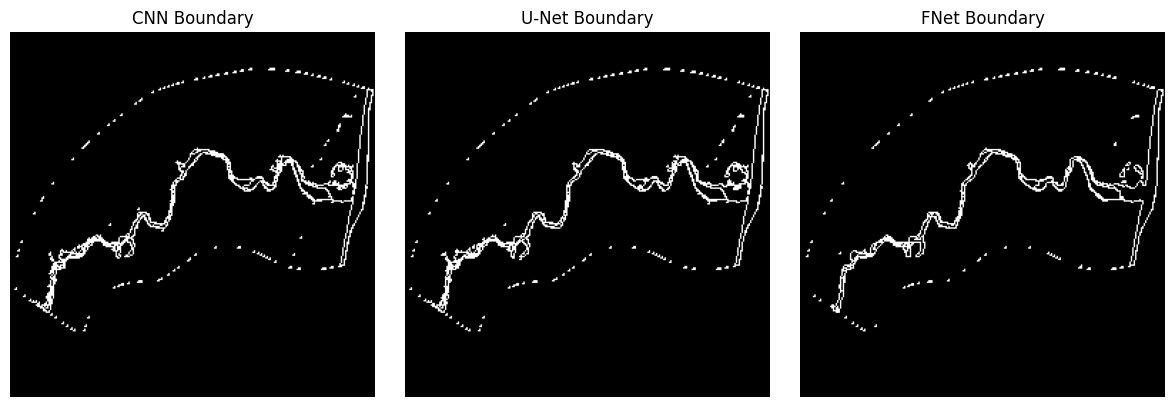

In [18]:

def get_boundary(mask):
    b = np.zeros_like(mask)
    b[:, :-1] |= (mask[:, :-1] != mask[:, 1:])
    b[:-1, :] |= (mask[:-1, :] != mask[1:, :])
    return b.astype(np.uint8) * 255


plt.figure(figsize=(12, 4))

# CNN
plt.subplot(1, 3, 1)
plt.imshow(get_boundary(pred_cnn), cmap='gray')
plt.title("CNN Boundary")
plt.axis('off')

# U-Net
plt.subplot(1, 3, 2)
plt.imshow(get_boundary(pred_unet), cmap='gray')
plt.title("U-Net Boundary")
plt.axis('off')

# FNet
plt.subplot(1, 3, 3)
plt.imshow(get_boundary(pred_fcnn), cmap='gray')
plt.title("FNet Boundary")
plt.axis('off')

plt.tight_layout()
plt.show()

In [14]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow.keras import layers, Model

# Defining the paths
train_folder = "flood_dataset/train"
test_folder = "flood_dataset/test"

#converts a colorful flood map image into a numerical "Label Map" (0, 1, 2, 3, 4)
def create_mask(img):
    colors = np.array([[0,255,0], [100,255,100], [0,255,255], [0,0,255], [0,0,139]])  # defining the 5 colours used in the flood image
    img_flat = img.reshape(-1,3)  # flattern 2D image into long list of pixels for faster calculation
    distances = np.linalg.norm(img_flat[:, None] - colors, axis=2)  # distance check: for every pixel, find which of the 5 colours is closest to
    mask = np.argmin(distances, axis=1)  # Assign the index (0 to 4) of the closest color to that pixel
    return mask.reshape(img.shape[0], img.shape[1])  # reshape back into 2D grid (256*256)

def load_from_directory(folder):
    images, masks = [], []
    files = sorted([f for f in os.listdir(folder) if f.endswith((".png", ".jpg", ".jpeg"))])  # file names in specified folder
    for filename in files:
        img = cv2.imread(os.path.join(folder, filename))
        #print(img.shape)
        img = cv2.resize(img, (256, 256))  # model requires all inputs in the same order
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # we convert to RGB for standard color processing
        images.append(img)
        masks.append(create_mask(img))  # Use our create_mask function to turn the image into a label map and add to mask list
    return np.array(images) / 255.0, np.array(masks), files # normalize pixel values (0-255) to a 0-1 range
    

# Load 40 images for training
train_images, train_masks, train_files = load_from_directory(train_folder)
# Load 12 images for testing
test_images, test_masks, test_files = load_from_directory(test_folder)

print(f"Loaded {len(train_images)} images for training.")
print(f"Loaded {len(test_images)} images for testing.")

Loaded 40 images for training.
Loaded 12 images for testing.


In [15]:
# 'conv_block' defines the double-layer convolution pattern used throughout the U-Net
def conv_block(x, filters):
    x = layers.Conv2D(filters, (3, 3), padding='same', activation='relu')(x)
    return layers.Conv2D(filters, (3, 3), padding='same', activation='relu')(x)

def build_unet():
    inputs = layers.Input((256, 256, 3))
    # Encoder(Down sampling): Reduces image size to capture "what" is in the image using skip connectios
    c1 = conv_block(inputs, 32); p1 = layers.MaxPooling2D((2, 2))(c1)
    c2 = conv_block(p1, 64); p2 = layers.MaxPooling2D((2, 2))(c2)
    # Bottleneck
    b1 = conv_block(p2, 128)
    # Decoder(Up sampling): Restores image size to capture "where" the flood is
    d1 = layers.Conv2DTranspose(64, (2, 2), strides=2, padding='same')(b1)
    d1 = layers.concatenate([d1, c2])
    d1 = conv_block(d1, 64)
    d2 = layers.Conv2DTranspose(32, (2, 2), strides=2, padding='same')(d1)
    d2 = layers.concatenate([d2, c1])
    d2 = conv_block(d2, 32)
    outputs = layers.Conv2D(5, (1, 1), activation='softmax')(d2)
    return Model(inputs, outputs)

# Simple CNN: A basic architecture without upsampling/downsampling logic
def build_cnn():
    return tf.keras.Sequential([
        layers.Input(shape=(256, 256, 3)),
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.Conv2D(5, (1, 1), activation='softmax')
    ])

# FCNN: Uses basic downsampling and upsampling but lacks the skip connections of U-Net
def build_fcnn():
    inputs = layers.Input((256, 256, 3))
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2DTranspose(64, (2, 2), strides=2, padding='same')(x)
    x = layers.Conv2DTranspose(32, (2, 2), strides=2, padding='same')(x)
    outputs = layers.Conv2D(5, (1, 1), activation='softmax')(x)
    return Model(inputs, outputs)

In [16]:
model_unet = build_unet()
model_cnn = build_cnn()
model_fcnn = build_fcnn()

all_models = {
    "CNN": model_cnn,
    "FCNN": model_fcnn,
    "U-Net": model_unet
}

for name, m in all_models.items():
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# --- 3. TRAINING ON THE 40 IMAGES ---

print("Starting training sequence...")

print("Training CNN...")
all_models["CNN"].fit(train_images, train_masks, epochs=50, batch_size=4, verbose=0)

print("Training FCNN...")
all_models["FCNN"].fit(train_images, train_masks, epochs=50, batch_size=4, verbose=0)

print("Training U-Net...")
all_models["U-Net"].fit(train_images, train_masks, epochs=50, batch_size=4, verbose=0)

print("\nAll models are now trained and ready for comparison!")

Starting training sequence...
Training CNN...
Training FCNN...
Training U-Net...

All models are now trained and ready for comparison!



--- Final Performance Comparison (12 Test Images) ---
   Model Test Accuracy  Test Loss
0    CNN        99.42%     0.0156
1   FCNN        97.93%     0.0581
2  U-Net        99.15%     0.0200


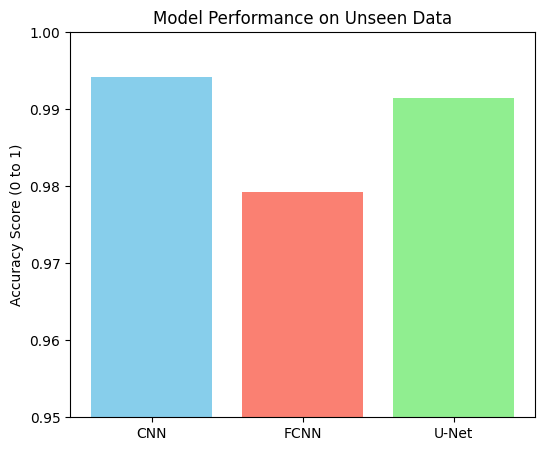

In [17]:


# This block calculates the average accuracy and loss for all 12 test images at once
evaluation_results = []

for name, m in all_models.items():
    loss, accuracy = m.evaluate(test_images, test_masks, verbose=0)
    
    evaluation_results.append({
        "Model": name,
        "Accuracy_Value": accuracy, # Keep as number for plotting
        "Test Accuracy": f"{accuracy:.2%}",
        "Test Loss": round(loss, 4)
    })

df_results = pd.DataFrame(evaluation_results)

# Print the table
print("\n--- Final Performance Comparison (12 Test Images) ---")
print(df_results[["Model", "Test Accuracy", "Test Loss"]])

# Fix: Plot using the numeric 'Accuracy_Value' column
plt.figure(figsize=(6, 5))
plt.bar(df_results['Model'], df_results['Accuracy_Value'], color=['skyblue', 'salmon', 'lightgreen'])
plt.ylabel("Accuracy Score (0 to 1)")
plt.title("Model Performance on Unseen Data")
plt.ylim(0.95, 1.0) 
plt.show()

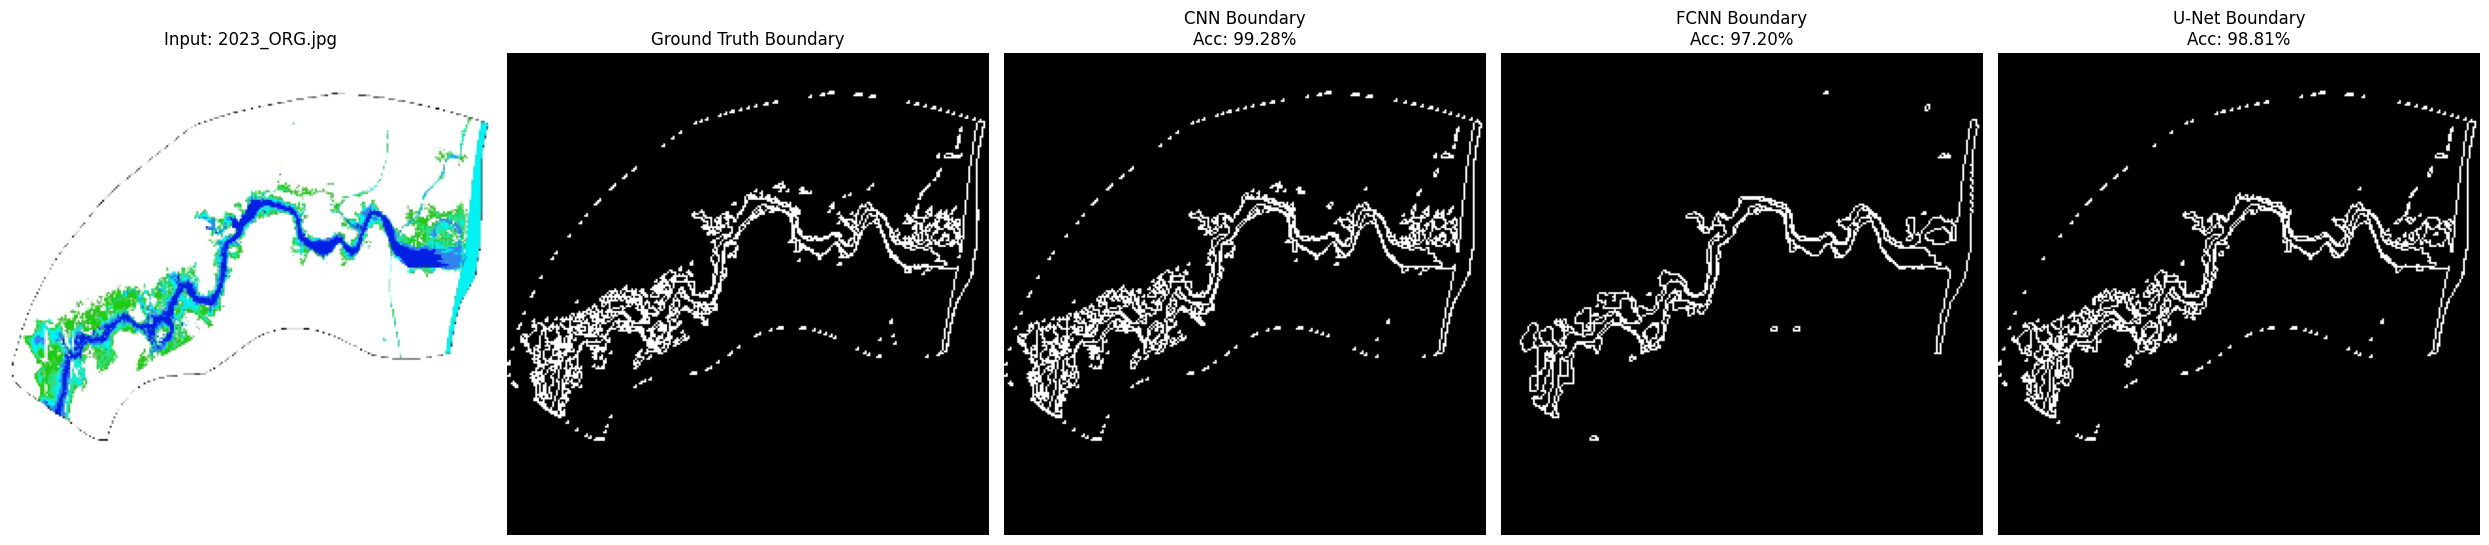

In [18]:
# we can change th efile name here
input_filename = "2023_ORG.jpg" 
# ------------------------------------

image_path = os.path.join(test_folder, input_filename)

# Mathematical logic to find pixels where the color/class changes (identifies the edges)
def get_boundary(mask):
    b = np.zeros_like(mask)
    b[:, :-1] |= (mask[:, :-1] != mask[:, 1:])
    b[:-1, :] |= (mask[:-1, :] != mask[1:, :])
    return b.astype(np.uint8) * 255

if not os.path.exists(image_path):
    print(f"❌ Error: {input_filename} not found in {test_folder}")
else:
    # Preprocessing the single input image to match training format
    img = cv2.imread(image_path)
    img = cv2.resize(img, (256, 256))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    true_mask = create_mask(img)
    true_boundary = get_boundary(true_mask)
    input_batch = np.expand_dims(img / 255.0, axis=0)

    # 2. Predict and Calculate Accuracy for each model
    results = {}
    accuracies = {}
    
    for name, m in all_models.items():
        pred = m.predict(input_batch, verbose=0)
        pred_mask = np.argmax(pred, axis=-1)[0]
        
        # Calculate accuracy for THIS specific image
        # (Number of correct pixels / Total number of pixels)
        acc = np.sum(pred_mask == true_mask) / true_mask.size
        
        results[name] = get_boundary(pred_mask)
        accuracies[name] = acc

    # 3. Plotting Side-by-Side
    plt.figure(figsize=(25, 6))

    # Input Image
    plt.subplot(1, 5, 1)
    plt.imshow(img)
    plt.title(f"Input: {input_filename}")
    plt.axis('off')

    # Ground Truth
    plt.subplot(1, 5, 2)
    plt.imshow(true_boundary, cmap='gray')
    plt.title("Ground Truth Boundary")
    plt.axis('off')

    # CNN Prediction
    plt.subplot(1, 5, 3)
    plt.imshow(results["CNN"], cmap='gray')
    plt.title(f"CNN Boundary\nAcc: {accuracies['CNN']:.2%}")
    plt.axis('off')

    # FCNN Prediction
    plt.subplot(1, 5, 4)
    plt.imshow(results["FCNN"], cmap='gray')
    plt.title(f"FCNN Boundary\nAcc: {accuracies['FCNN']:.2%}")
    plt.axis('off')

    # U-Net Prediction
    plt.subplot(1, 5, 5)
    plt.imshow(results["U-Net"], cmap='gray')
    plt.title(f"U-Net Boundary\nAcc: {accuracies['U-Net']:.2%}")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

